# Seaborn Iris 데이터셋 다중 분류 모델
이 노트북은 **TensorFlow/Keras**를 사용하여 Iris 꽃의 3가지 품종을 분류하는 딥러닝 모델을 구축하고 평가합니다.

In [1]:
# 1. 라이브러리 임포트
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, utils
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.22.0-rc0


In [2]:
# 2. 데이터 로드
df = sns.load_dataset('iris')
print("데이터 샘플:")
print(df.head())

데이터 샘플:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [3]:
# 3. 데이터 전처리
# 레이블(species) 인코딩 (문자열 -> 정수)
df['species'] = df['species'].astype('category').cat.codes

# 특성과 타겟 분리
X = df.drop('species', axis=1).values.astype(np.float32)
y = df['species'].values.astype(np.int32)

# 타겟 원-핫 인코딩
y_encoded = utils.to_categorical(y)

# 데이터 분할 (Train/Test)
np.random.seed(42)
indices = np.random.permutation(len(X))
train_size = int(len(X) * 0.8)
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

In [7]:
# 4. Keras 모델 구조 정의
model = models.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='softmax') # 다중 분류를 위한 출력층
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,499 (9.76 KB)

 Trainable params: 2,499 (9.76 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 5. 모델 학습 (EarlyStopping 포함)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=1000,
    batch_size=8,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.3542 - loss: 1.0386 - val_accuracy: 0.3750 - val_loss: 0.8931
Epoch 2/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5312 - loss: 0.8864 - val_accuracy: 0.7917 - val_loss: 0.7932
Epoch 3/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7604 - loss: 0.7855 - val_accuracy: 0.8333 - val_loss: 0.7344
Epoch 4/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8438 - loss: 0.7040 - val_accuracy: 0.7500 - val_loss: 0.6497
Epoch 5/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7812 - loss: 0.6346 - val_accuracy: 0.8333 - val_loss: 0.5873
Epoch 6/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8542 - loss: 0.5758 - val_accuracy: 0.8333 - val_loss: 0.5394
Epoch 7/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8542 - loss: 0.5276 - val_accuracy: 0.8333 - val_loss: 0.4987
Epoch 8/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9062 - loss: 0.4906 - val_accu

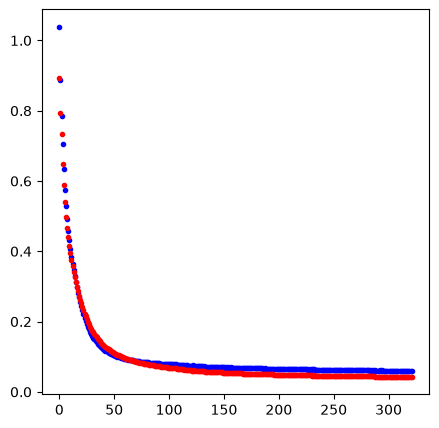

In [9]:
plt.figure(figsize=(5,5))
plt.plot(history.history["loss"], 'b.')
plt.plot(history.history["val_loss"], 'r.')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step


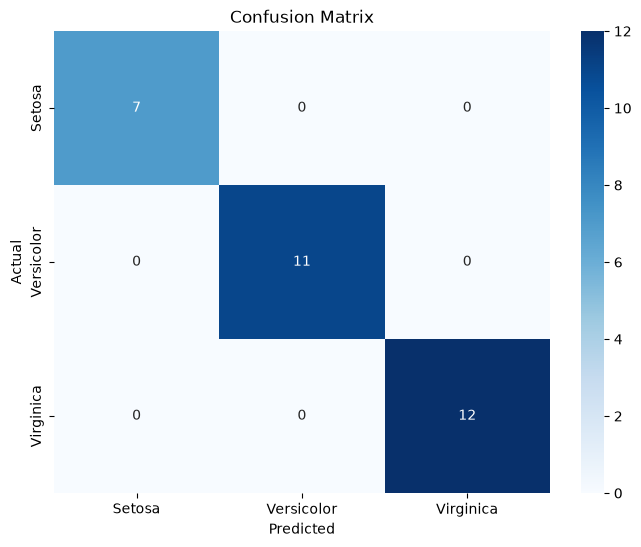

In [10]:
# 6. 모델 평가 및 오차 행렬(Confusion Matrix) 시각화
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# 혼동 행렬 직접 계산 (Numpy 활용)
cm = np.zeros((3, 3), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Setosa', 'Versicolor', 'Virginica'],
            yticklabels=['Setosa', 'Versicolor', 'Virginica'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()